In [1]:
import os
import numpy as np
import pandas as pd

import librosa
import librosa.display

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from PIL import Image

In [2]:
DATASET_ROOT = "/kaggle/input/datasets/subihanbiswas/voxceleb1-210-logmel-images"

train_df = pd.read_csv(f"{DATASET_ROOT}/train.csv")
val_df = pd.read_csv(f"{DATASET_ROOT}/val.csv")
test_df = pd.read_csv(f"{DATASET_ROOT}/test.csv")

In [3]:
print(train_df.head())
print(val_df.head())
print(test_df.head())

                                       path speaker_id  label
0  mel_images/id10376/R9MnSbVgqjs/00001.png    id10376     51
1  mel_images/id10376/OSUGWP3iYns/00018.png    id10376     51
2  mel_images/id10376/q4s0M2lP_RE/00001.png    id10376     51
3  mel_images/id10376/veSad9Nigl4/00015.png    id10376     51
4  mel_images/id10376/OSUGWP3iYns/00014.png    id10376     51
                                       path speaker_id  label
0  mel_images/id10376/veSad9Nigl4/00008.png    id10376     51
1  mel_images/id10376/hwtznlwVgkg/00019.png    id10376     51
2  mel_images/id10376/OSUGWP3iYns/00007.png    id10376     51
3  mel_images/id10376/Xo3NYYGZw1c/00008.png    id10376     51
4  mel_images/id10376/mk1UmZlF7XU/00005.png    id10376     51
                                       path speaker_id  label
0  mel_images/id10376/v8DrrmZepYg/00009.png    id10376     51
1  mel_images/id10376/pdLpwxLCcHo/00003.png    id10376     51
2  mel_images/id10376/FgnnQTkhVXE/00004.png    id10376     51
3  mel_i

In [4]:
import random
import torch

class SpecAugment:

    def __init__(
        self,
        freq_mask_param=15,
        time_mask_param=30
    ):

        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def __call__(self, x):

        # x: [C,H,W]

        _, H, W = x.shape

        # Frequency masking
        f = random.randint(
            0,
            self.freq_mask_param
        )

        if f > 0:

            f0 = random.randint(
                0,
                H - f
            )

            x[:, f0:f0+f, :] = 0

        # Time masking
        t = random.randint(
            0,
            self.time_mask_param
        )

        if t > 0:

            t0 = random.randint(
                0,
                W - t
            )

            x[:, :, t0:t0+t] = 0

        return x

In [5]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import os
import torch


class VoxCelebDataset(Dataset):

    def __init__(
        self,
        dataframe,
        root_dir,
        transform=None
    ):

        self.root_dir = root_dir
    
        self.paths = dataframe["path"].tolist()
        self.labels = dataframe["label"].tolist()
    
        self.transform = transform

    def __len__(self):

        return len(self.paths)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.root_dir,
            self.paths[idx]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:

            image = self.transform(image)

        label = self.labels[idx]

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [6]:
train_transform = transforms.Compose([

    transforms.ToTensor(),

    SpecAugment(
        freq_mask_param=10,
        time_mask_param=20
    )
])

val_test_transform = transforms.ToTensor()

In [7]:
train_dataset = VoxCelebDataset(
    train_df,
    DATASET_ROOT,
    transform=train_transform
)

val_dataset = VoxCelebDataset(
    val_df,
    DATASET_ROOT,
    transform=val_test_transform
)

test_dataset = VoxCelebDataset(
    test_df,
    DATASET_ROOT,
    transform=val_test_transform
)

In [8]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(51)


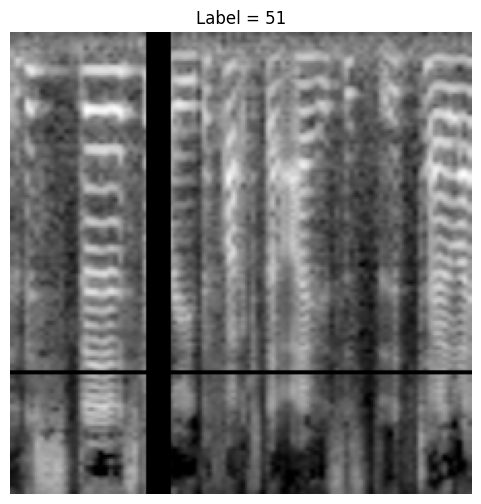

In [9]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.figure(figsize=(6,6))

plt.imshow(
    image.permute(1,2,0)
)

plt.title(f"Label = {label}")
plt.axis("off")
plt.show()

In [10]:
image, label = train_dataset[0]

print(image.shape)
print(image.min())
print(image.max())

torch.Size([3, 224, 224])
tensor(0.)
tensor(1.)


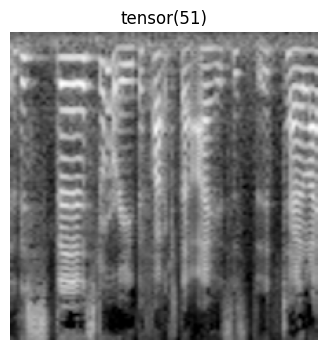

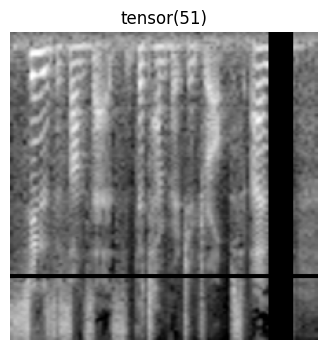

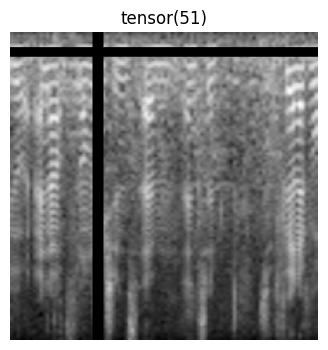

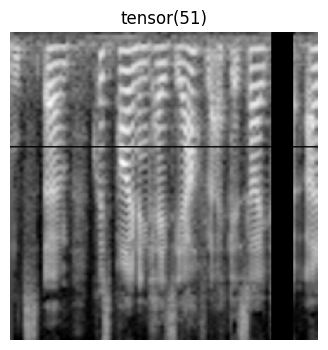

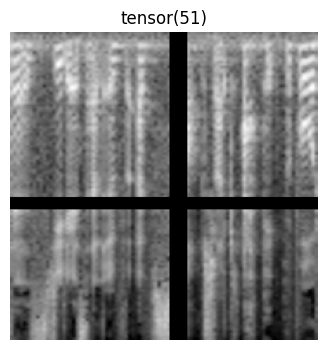

In [11]:
for i in range(5):

    image, label = train_dataset[i]

    plt.figure(figsize=(4,4))

    plt.imshow(
        image.permute(1,2,0)
    )

    plt.title(label)

    plt.axis("off")

    plt.show()

In [12]:
BATCH_SIZE=32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [13]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
# device = torch.device(
#     "cuda" if torch.cuda.is_available() else "cpu"
# )

# print(device)

In [15]:
import torch
import torch.nn as nn

In [16]:
class DSCBlock(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            # Depthwise convolution
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=1,
                groups=in_channels,
                bias=False
            ),

            nn.BatchNorm2d(in_channels),
            nn.GELU(),

            # Pointwise convolution
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.GELU()
        )

    def forward(self, x):

        return self.block(x)

In [17]:
class CNNDSCBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # -------- 224×224 --------

            nn.Conv2d(3,16,3,padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.Conv2d(16,16,3,padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),

            DSCBlock(16,16),

            nn.Conv2d(16,16,3,padding=1,bias=False),
            nn.BatchNorm2d(16),
            nn.GELU(),

            DSCBlock(16,16),

            # -------- 112×112 --------

            nn.Conv2d(16,32,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),

            DSCBlock(32,32),

            nn.Conv2d(32,32,3,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),

            DSCBlock(32,32),

            # -------- 56×56 --------

            nn.Conv2d(32,64,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),

            DSCBlock(64,64),

            nn.Conv2d(64,64,3,padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),

            DSCBlock(64,64),

            # -------- 28×28 --------

            nn.Conv2d(64,128,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),

            DSCBlock(128,128),

            nn.Conv2d(128,128,3,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.GELU(),

            DSCBlock(128,128),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128,256),

            nn.BatchNorm1d(256),

            nn.GELU(),

            nn.Dropout(0.4)
        )


    def forward(self, x):

        x = self.features(x)

        x = self.fc(x)

        return x

In [18]:
model = CNNDSCBranch()

x = torch.randn(8,3,224,224)

y = model(x)

print(y.shape)

torch.Size([8, 256])


In [19]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 379,632
Trainable parameters: 379,632


In [20]:
import timm

fastvit = timm.create_model(
    "fastvit_sa12.apple_in1k",
    pretrained=True,
    num_classes=0
)

model.safetensors:   0%|          | 0.00/46.5M [00:00<?, ?B/s]

In [21]:
x = torch.randn(8,3,224,224)

y = fastvit(x)

print(y.shape)

torch.Size([8, 1024])


In [22]:
for p in fastvit.parameters():
    p.requires_grad = True

In [23]:
class HybridSpeechModel(nn.Module):

    def __init__(self,
                 fastvit_model,
                 num_classes=210):

        super().__init__()

        self.fastvit = fastvit_model

        self.cnn_branch = CNNDSCBranch()

        self.classifier = nn.Sequential(

            nn.Linear(1024 + 256, 1024),

            nn.BatchNorm1d(1024),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(1024, 512),

            nn.BatchNorm1d(512),

            nn.GELU(),

            nn.Dropout(0.3)
        )

        self.fc_out = nn.Linear(
            512,
            num_classes
        )

    def forward(self, x):

        # FastViT branch
        fastvit_feature = self.fastvit(x)

        # CNN-DSC branch
        cnn_feature = self.cnn_branch(x)

        # Feature fusion
        combined = torch.cat(
            [fastvit_feature, cnn_feature],
            dim=1
        )

        # 512-dimensional embedding
        embedding = self.classifier(combined)

        # Classification layer
        logits = self.fc_out(embedding)

        return logits, embedding

In [24]:
print(next(fastvit.parameters()).device)

cpu


In [25]:
device = torch.device("cuda")

model = HybridSpeechModel(
    fastvit_model=fastvit,
    num_classes=210
)

model = model.to(device)

print(device)

cuda


In [26]:
# model = HybridSpeechModel(
#     fastvit_model=fastvit,
#     num_classes=210
# )

# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)

# model = model.to(device)

In [27]:
x = torch.randn(
    8,
    3,
    224,
    224,
    device=device
)

with torch.no_grad():
    logits, embedding = model(x)

print(logits.shape)
print(embedding.shape)

torch.Size([8, 210])
torch.Size([8, 512])


In [28]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 12,882,946
Trainable parameters: 12,882,946


In [29]:
!pip install torchinfo

In [30]:
from torchinfo import summary

summary(
    model,
    input_size=(32, 3, 224, 224),
    col_names=[
        "input_size",
        "output_size",
        "num_params",
        "trainable"
    ]
)

Layer (type:depth-idx)                                                      Input Shape               Output Shape              Param #                   Trainable
HybridSpeechModel                                                           [32, 3, 224, 224]         [32, 210]                 --                        True
├─FastVit: 1-1                                                              [32, 3, 224, 224]         [32, 1024]                --                        True
│    └─Sequential: 2-1                                                      [32, 3, 224, 224]         [32, 64, 56, 56]          --                        True
│    │    └─MobileOneBlock: 3-1                                             [32, 3, 224, 224]         [32, 64, 112, 112]        2,176                     True
│    │    └─MobileOneBlock: 3-2                                             [32, 64, 112, 112]        [32, 64, 56, 56]          896                       True
│    │    └─MobileOneBlock: 3-3          

In [31]:
# base_model = model.module if isinstance(
#     model,
#     nn.DataParallel
# ) else model


# optimizer = torch.optim.AdamW([
#     {"params": base_model.fastvit.parameters(), "lr": 1e-5},
#     {"params": base_model.cnn_branch.parameters(), "lr": 1e-4},
#     {"params": base_model.classifier.parameters(), "lr": 1e-4},
#     {"params": base_model.fc_out.parameters(), "lr": 1e-4} ],
#     weight_decay=1e-4)

optimizer = torch.optim.AdamW([
        {"params": model.fastvit.parameters(),"lr": 1e-5},
        {"params": model.cnn_branch.parameters(),"lr": 1e-4},
        {"params": model.classifier.parameters(),"lr": 1e-4},
        {"params": model.fc_out.parameters(),"lr": 1e-4}
        ],
    weight_decay=1e-4
)


In [32]:
# criterion = nn.CrossEntropyLoss()

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [33]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [34]:
scaler = torch.amp.GradScaler("cuda")

In [35]:

def train_one_epoch(
        model,
        loader,
        criterion,
        optimizer,
        scaler,
        device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)
        

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        pbar.set_postfix(
            loss=running_loss/total,
            acc=correct/total
        )

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [36]:
@torch.no_grad()
def validate(
        model,
        loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):

            outputs, embedding  = model(images)

            loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [37]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.amp.autocast('cuda'):
    outputs, embedding  = model(images)
    loss = criterion(outputs, labels)

print(outputs.requires_grad)
print(loss.requires_grad)

True
True


In [38]:
import matplotlib.pyplot as plt

def plot_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14,5))

    # Loss
    plt.subplot(1,2,1)

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")

    plt.legend()

    plt.grid(True)

    # Accuracy
    plt.subplot(1,2,2)

    plt.plot(
        epochs,
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [39]:
from tqdm.auto import tqdm
import torch


def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        scaler,
        device,
        initial_epochs=50,
        patience=10
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    early_stop_counter = 0
    current_epoch = 0
    epochs_to_run = initial_epochs

    while True:

        for _ in range(epochs_to_run):

            current_epoch += 1

            # ==========================
            # Training
            # ==========================
            train_loss, train_acc = train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                device
            )

            # ==========================
            # Validation
            # ==========================
            val_loss, val_acc = validate(
                model,
                val_loader,
                criterion,
                device
            )

            # ==========================
            # Scheduler
            # ==========================
            scheduler.step(val_acc)

            # ==========================
            # Save history
            # ==========================
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            # ==========================
            # Print epoch results
            # ==========================
            print(
                f"Epoch [{current_epoch}] "
                f"| Train Loss: {train_loss:.4f}"
                f" | Train Acc: {train_acc:.4f}"
                f" | Val Loss: {val_loss:.4f}"
                f" | Val Acc: {val_acc:.4f}"
            )

            # ==========================
            # Save best model
            # ==========================
            if val_acc > best_val_acc:

                best_val_acc = val_acc
                early_stop_counter = 0

                torch.save(
                    model.state_dict(),
                    "best_model.pth"
                )
                # torch.save(
                #     (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
                #     "best_model.pth"
                # )
                

                print(
                    f"Best model saved! "
                    f"(Val Acc = {best_val_acc:.4f})"
                )

            else:

                early_stop_counter += 1

            # ==========================
            # Save last model
            # ==========================
            
            torch.save(
                model.state_dict(),
                "last_model.pth"
            )
            # torch.save(
            #     (model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()),
            #     "last_model.pth"
            # )

            # ==========================
            # Early stopping
            # ==========================
            if early_stop_counter >= patience:

                print("\nEarly stopping triggered!")

                return history, best_val_acc

        # =====================================
        # Ask whether to continue training
        # =====================================
        answer = input(
            "\nContinue training? (y/n): "
        ).lower()

        if answer != "y":

            print("\nTraining finished.")

            break

        epochs_to_run = int(
            input(
                "How many more epochs? "
            )
        )

    # return history, best_val_acc
    plot_history(history)

    return history, best_val_acc

  0%|          | 0/1167 [00:00<?, ?it/s]

Epoch [1] | Train Loss: 5.0137 | Train Acc: 0.0465 | Val Loss: 4.5215 | Val Acc: 0.1097
Best model saved! (Val Acc = 0.1097)


  0%|          | 0/1167 [00:00<?, ?it/s]

Epoch [2] | Train Loss: 4.2632 | Train Acc: 0.1546 | Val Loss: 3.8144 | Val Acc: 0.2604
Best model saved! (Val Acc = 0.2604)


  0%|          | 0/1167 [00:00<?, ?it/s]

...

Epoch [39] | Train Loss: 1.0251 | Train Acc: 0.9965 | Val Loss: 1.2414 | Val Acc: 0.9234
Best model saved! (Val Acc = 0.9234)


  0%|          | 0/1167 [00:00<?, ?it/s]

Epoch [40] | Train Loss: 1.0204 | Train Acc: 0.9970 | Val Loss: 1.2446 | Val Acc: 0.9223



Continue training? (y/n):  n



Training finished.


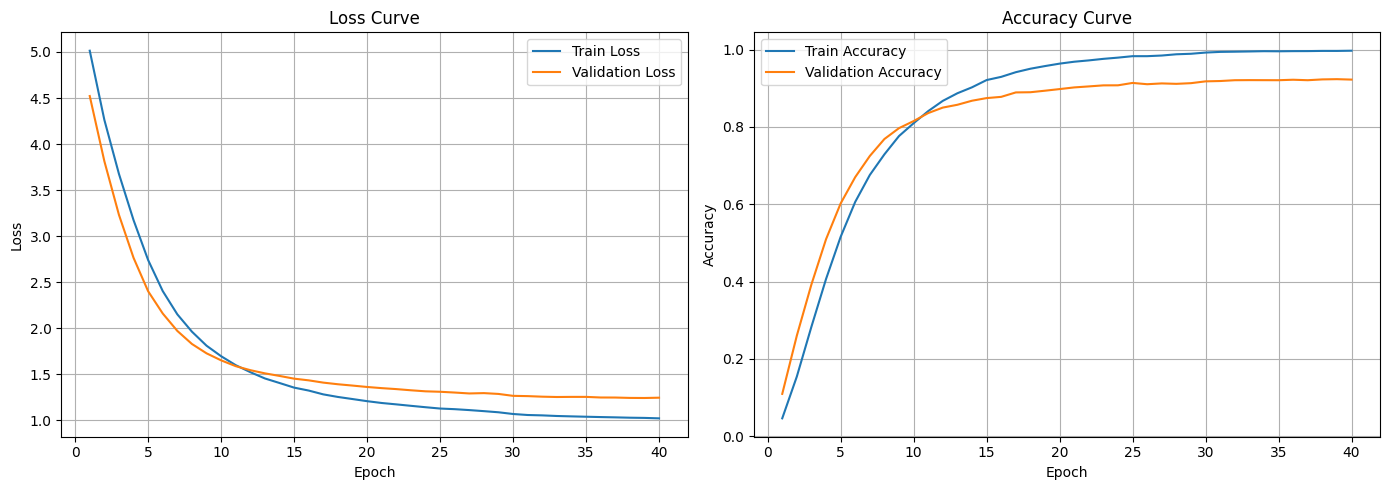

In [40]:
history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    initial_epochs=20,
    patience=10
)

In [41]:
import torch
import numpy as np
from tqdm.auto import tqdm


@torch.no_grad()
def test_model(
        model,
        test_loader,
        criterion,
        device
):

    model.eval()

    running_loss = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    pbar = tqdm(test_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        with torch.amp.autocast('cuda'):

            outputs, embedding = model(images)

            loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)

        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

    test_loss = running_loss / total

    return (
        test_loss,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )

In [42]:
from sklearn.metrics import (
    accuracy_score,
    top_k_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_metrics(
        test_loss,
        all_labels,
        all_preds,
        all_probs
):

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    top3_acc = top_k_accuracy_score(
        all_labels,
        all_probs,
        k=3
    )

    top5_acc = top_k_accuracy_score(
        all_labels,
        all_probs,
        k=5
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    report = classification_report(
        all_labels,
        all_preds
    )

    print("="*50)
    print(f"Test Loss      : {test_loss:.4f}")
    print(f"Top-1 Accuracy : {accuracy:.4f}")
    print(f"Top-3 Accuracy : {top3_acc:.4f}")
    print(f"Top-5 Accuracy : {top5_acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print("="*50)

    print("\nClassification Report:\n")

    print(report)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        cmap='Blues'
    )

    plt.title("Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

    results = {

        "test_loss": test_loss,

        "accuracy": accuracy,

        "top3_accuracy": top3_acc,

        "top5_accuracy": top5_acc,

        "precision": precision,

        "recall": recall,

        "f1_score": f1,

        "confusion_matrix": cm,

        "classification_report": report

    }

    return results

  0%|          | 0/255 [00:00<?, ?it/s]

Test Loss      : 1.2361
Top-1 Accuracy : 0.9241
Top-3 Accuracy : 0.9720
Top-5 Accuracy : 0.9819
Precision      : 0.9265
Recall         : 0.9241
F1 Score       : 0.9239

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        38
           1       0.95      1.00      0.98        41
           2       0.97      0.99      0.98        89
           3       0.97      1.00      0.98        32
           4       0.93      0.93      0.93        30
           5       0.83      0.79      0.81        38
           6       0.91      0.96      0.93        45
           7       0.85      0.94      0.89        31
           8       0.97      0.90      0.93        31
           9       0.79      0.83      0.81        41
          10       0.94      0.94      0.94        35
          11       0.99      0.95      0.97        99
          12       0.89      0.91      0.90        45
          13       0.98      0.94      0.96       

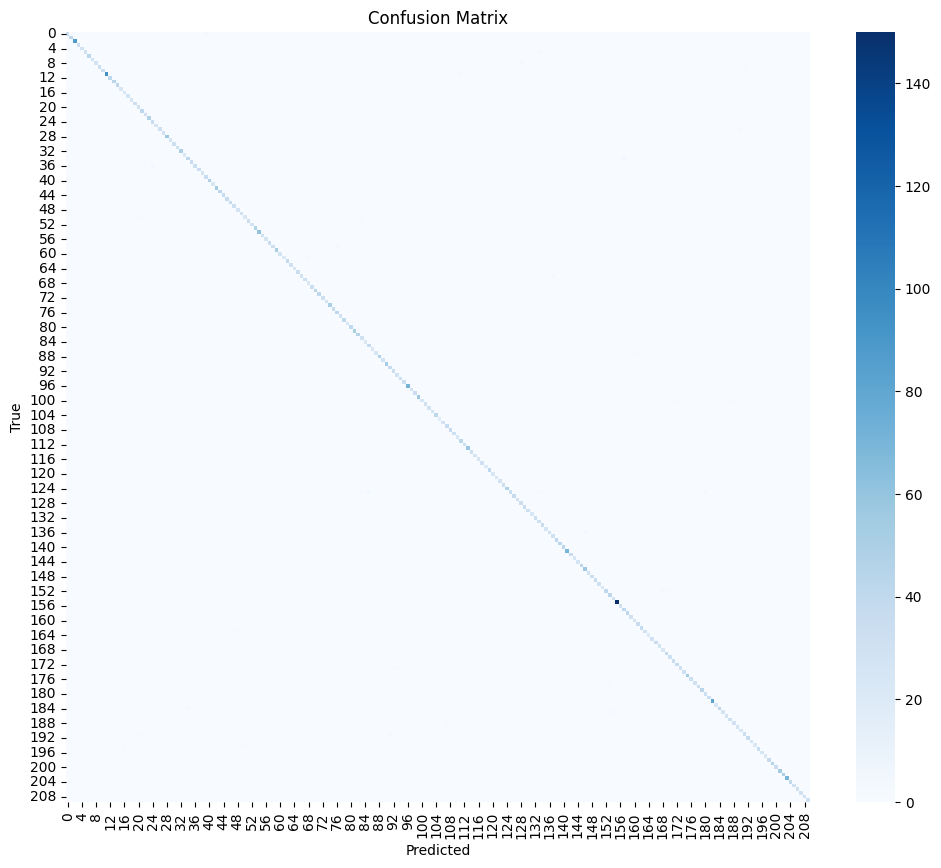

In [43]:
test_loss, labels, preds, probs = test_model(
    model,
    test_loader,
    criterion,
    device=device
)

results = evaluate_metrics(
    test_loss,
    labels,
    preds,
    probs
)